# Titanic — EDA & Baseline Model
**Goal:** Explore the dataset, clean data, create features, build a baseline logistic regression model, and present conclusions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
pd.set_option('display.max_columns', 100)


In [2]:
df = pd.read_csv("D:/STUDY/python-basics/data/titanic_train.csv")
df.head()
df.shape


(200, 10)

In [3]:
df.info()
df.describe(include='all')
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  200 non-null    int64  
 1   Pclass    200 non-null    int64  
 2   Name      200 non-null    object 
 3   Sex       200 non-null    object 
 4   Age       200 non-null    float64
 5   SibSp     200 non-null    int64  
 6   Parch     200 non-null    int64  
 7   Ticket    200 non-null    int64  
 8   Fare      200 non-null    float64
 9   Embarked  200 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 15.8+ KB


Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

Text(0.5, 1.0, 'Survival by Pclass')

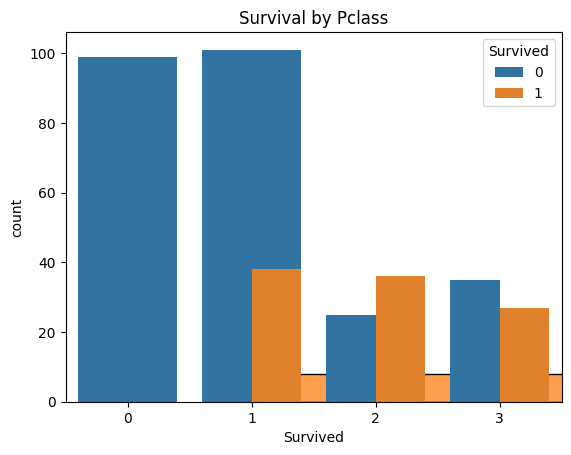

In [4]:
sns.countplot(x='Survived', data=df)
plt.title('Survival counts')

sns.histplot(df['Age'].dropna(), bins=20)
plt.title('Age distribution')

sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Pclass')


In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Other')
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,20,40,120], labels=['Child','Teen','Adult','Senior'])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df_model = df[['Survived','Pclass','Sex','Age','Fare','Embarked','Title','AgeGroup','FamilySize']]


In [9]:
df_model = pd.get_dummies(df_model, columns=['Sex','Embarked','Title','AgeGroup'], drop_first=True)
df_model = df_model.fillna(0)


In [10]:
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, pred))
print(classification_report(y_val, pred))


Accuracy: 0.425
              precision    recall  f1-score   support

           0       0.40      0.30      0.34        20
           1       0.44      0.55      0.49        20

    accuracy                           0.42        40
   macro avg       0.42      0.43      0.42        40
weighted avg       0.42      0.42      0.42        40



,feature,coef
6,Embarked_S,0.580671
4,Sex_male,0.346976
5,Embarked_Q,0.124281
1,Age,0.006020
2,Fare,0.004570
0,Pclass,-0.012662
10,Title_Title4,-0.091019
3,FamilySize,-0.091512
13,AgeGroup_Senior,-0.162376
12,AgeGroup_Adult,-0.219927


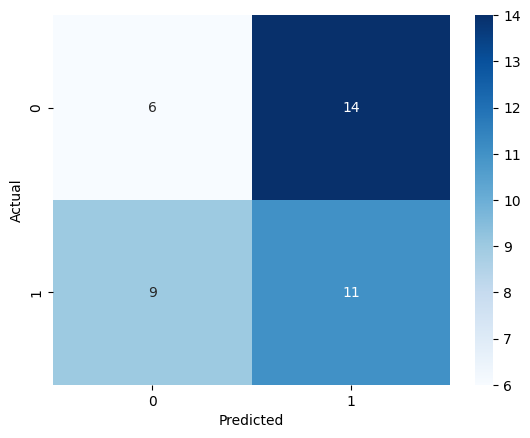

In [11]:
cm = confusion_matrix(y_val, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')

# Coefficients (approx feature importance)
coef_df = pd.DataFrame({'feature': X.columns, 'coef': model.coef_[0]})
coef_df.sort_values(by='coef', ascending=False).head(10)
